In [1]:
# Part 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# PART 2 : LOAD DATASET

data = pd.read_excel("../data/hourlyLoadDataIndia.xlsx")

print("Dataset Loaded Successfully")

print("\nFirst 5 rows:")
display(data.head())

print("\nAvailable Columns:")
print(data.columns)

print("\nDataset Shape:", data.shape)

Dataset Loaded Successfully

First 5 rows:


,datetime,National Hourly Demand,Northen Region Hourly Demand,Western Region Hourly Demand,Eastern Region Hourly Demand,Southern Region Hourly Demand,North-Eastern Region Hourly Demand
0,2019-01-01 00:00:00,118690.67,33692.02,38522.22,13128.89,31681.83,1665.72
1,2019-01-01 01:00:00,116029.23,32534.39,38071.09,12737.53,31129.97,1556.24
2,2019-01-01 02:00:00,114044.14,31730.37,37680.10,12387.36,30760.87,1485.44
3,2019-01-01 03:00:00,113648.97,31529.25,37747.37,12301.12,30616.27,1454.96
4,2019-01-01 04:00:00,116290.05,32406.61,38101.80,12479.13,31839.38,1463.14



Available Columns:
Index(['datetime', 'National Hourly Demand', 'Northen Region Hourly Demand',
       'Western Region Hourly Demand', 'Eastern Region Hourly Demand',
       'Southern Region Hourly Demand', 'North-Eastern Region Hourly Demand'],
      dtype='str')

Dataset Shape: (46728, 7)


In [3]:
# PART 3 : DATA CLEANING & FEATURE CREATION

data['datetime'] = pd.to_datetime(data['datetime'], errors='coerce')

data['Year'] = data['datetime'].dt.year
data['Month'] = data['datetime'].dt.month
data['Day'] = data['datetime'].dt.day
data['Hour'] = data['datetime'].dt.hour

data = data.dropna(subset=['National Hourly Demand'])

X = data[['Year','Month','Day','Hour']]
y = data['National Hourly Demand']

print("Feature sample:")
display(X.head())

Feature sample:


,Year,Month,Day,Hour
0,2019,1,1,0
1,2019,1,1,1
2,2019,1,1,2
3,2019,1,1,3
4,2019,1,1,4


In [4]:
# PART 4 : MODEL TRAINING

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=150,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Model training completed")

Model training completed


In [5]:
# PART 5 : MODEL EVALUATION

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("Model Evaluation Results")

print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("R² Score :", round(r2,4))

Model Evaluation Results
MAE : 1893.8
MSE : 7307285.71
R² Score : 0.9865


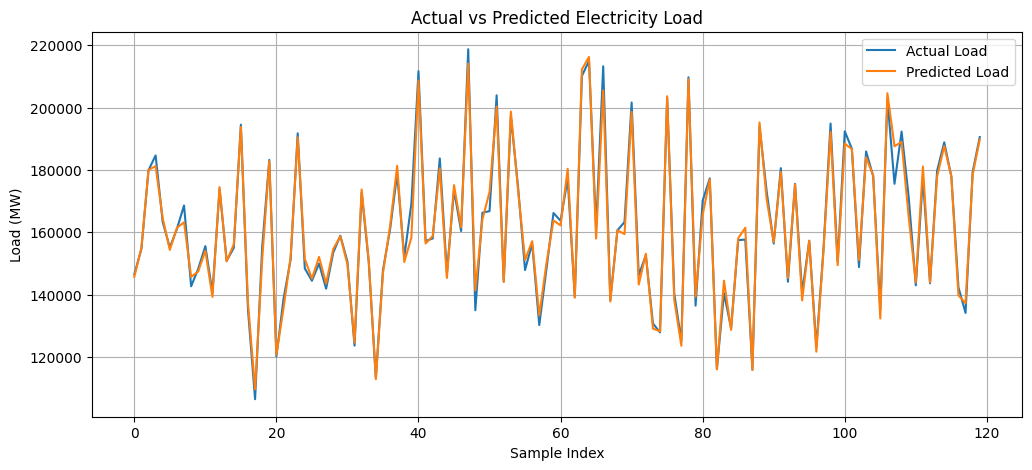

In [6]:
# GRAPH 1 : ACTUAL VS PREDICTED

plt.figure(figsize=(12,5))

n = 120

plt.plot(y_test.values[:n], label="Actual Load")
plt.plot(y_pred[:n], label="Predicted Load")

plt.xlabel("Sample Index")
plt.ylabel("Load (MW)")
plt.title("Actual vs Predicted Electricity Load")

plt.legend()
plt.grid(True)

plt.show()

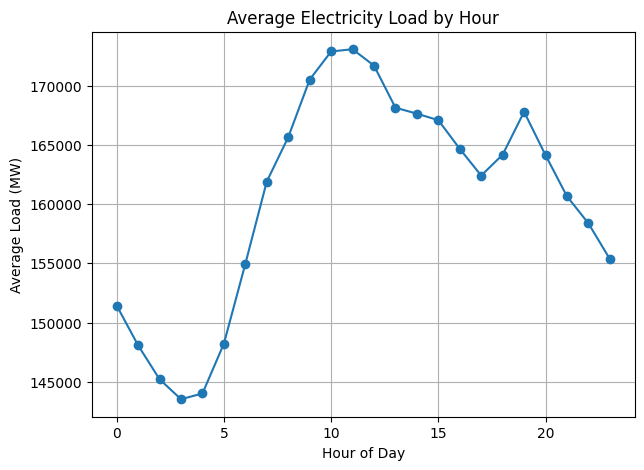

In [7]:
# GRAPH 2 : AVERAGE LOAD BY HOUR

hourly_avg = data.groupby("Hour")["National Hourly Demand"].mean()

plt.figure(figsize=(7,5))

plt.plot(hourly_avg.index, hourly_avg.values, marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("Average Load (MW)")
plt.title("Average Electricity Load by Hour")

plt.grid(True)

plt.show()